- [] Analyze category correlation to views/likes/dislikes etc
- [] Analyze relationship between US category popularity and other countries

### ToDo:
- Evolution of Category popularity over time in some capacity (days, weeks, whatever)
- Correlation between category and likes/dislikes
- Correlation between category and comment count
- Correlation between category and all numerics lmao
- Compare above information to other countries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
us_df = pd.read_csv("data/USvideos.csv")
us_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [2]:
def make_tag_dict(filepath):
    cat = pd.read_json(filepath)
    new_dict = {}
    for i in range(len(cat["items"])):
        new_dict[cat["items"][i]["id"]] = cat["items"][i]["snippet"]["title"]
    
    return new_dict

fetch_dict = make_tag_dict("data/US_category_id.json")

def fetch_tag(category_id):
    return fetch_dict[str(category_id)]

print(fetch_tag("43"))

Shows


In [8]:
us_df["category_name"] = us_df["category_id"].apply(fetch_tag)

us_df.sample(5)



,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
10465,9sbnGfWaOwQ,18.05.01,Kris Wu Schools Sean Evans on Regional Chinese...,First We Feast,26,2018-01-02T16:00:00.000Z,"First we feast|""fwf""|""firstwefeast""|""food""|""fo...",340422,12400,212,1231,https://i.ytimg.com/vi/9sbnGfWaOwQ/default.jpg,False,False,False,"As an international pop star, Kris Wu has eate...",Howto & Style
277,fcVjitaM3LY,17.15.11,78557 and Proth Primes - Numberphile,Numberphile,28,2017-11-13T12:13:36.000Z,"numberphile|""prime numbers""|""proth prime""",158173,6587,68,611,https://i.ytimg.com/vi/fcVjitaM3LY/default.jpg,False,False,False,James Grime is back and talking prime numbers....,Science & Technology
10901,3mB2fIt7vzw,18.07.01,Nintendo Switch Now the Fastest-Selling Home C...,IGN News,20,2018-01-04T14:48:10.000Z,"IGN|""games""|""Switch""|""Feature""|""Hardware""|""Nin...",8110,302,16,197,https://i.ytimg.com/vi/3mB2fIt7vzw/default.jpg,False,False,False,The hybrid console sells 4.8 million units in ...,Gaming
26412,m1-rpd3S-48,18.28.03,[OFFICIAL VIDEO] Attention - Pentatonix,PTXofficial,10,2018-03-23T13:59:32.000Z,"Pentatonix|""Penatonix""|""PTX""|""PTXofficial""|""Mi...",4199247,240449,4250,13427,https://i.ytimg.com/vi/m1-rpd3S-48/default.jpg,False,False,False,"PRE-ORDER PTX PRESENTS: TOP POP, VOL. I FEATUR...",Music
32662,D5D90CLAILY,18.04.05,Priyanka Chopra 'struggling' to find wedding g...,Good Morning America,24,2018-04-26T14:08:10.000Z,"priyanka|""chopra""|""quantico""|""actress""|""meghan...",419784,3862,229,659,https://i.ytimg.com/vi/D5D90CLAILY/default.jpg,False,False,False,The Quantico star appeared live on GMA to disc...,Entertainment


<Axes: ylabel='category_name'>

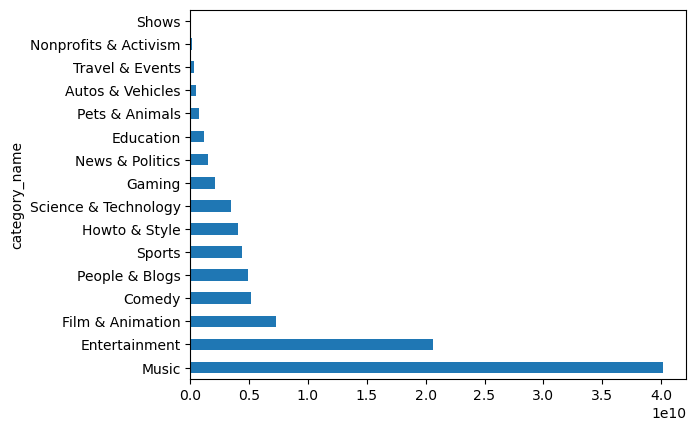

In [4]:
us_df_reduced = us_df.drop(columns=["thumbnail_link", "video_id", "comments_disabled", "description", "ratings_disabled", "video_error_or_removed"])
us_df_reduced["trending_date"] = pd.to_datetime(us_df_reduced["trending_date"], format="%y.%d.%m")
us_df_reduced["publish_time"] = pd.to_datetime(us_df_reduced["publish_time"])
us_df_reduced.sort_values("trending_date", ascending=False)
us_df_reduced.groupby("category_name")["views"].sum().sort_values(ascending=False)

us_df_reduced.groupby("category_name")["views"].sum().sort_values(ascending=False).plot(kind="barh")

In [5]:
us_df_reduced.groupby("category_id")["views"].sum().sort_values(ascending=False)

us_df_reduced.corr(numeric_only=True)


,category_id,views,likes,dislikes,comment_count
category_id,1.000000,-0.168231,-0.173921,-0.033547,-0.076307
views,-0.168231,1.000000,0.849177,0.472213,0.617621
likes,-0.173921,0.849177,1.000000,0.447186,0.803057
dislikes,-0.033547,0.472213,0.447186,1.000000,0.700184
comment_count,-0.076307,0.617621,0.803057,0.700184,1.000000


<Axes: ylabel='category_name'>

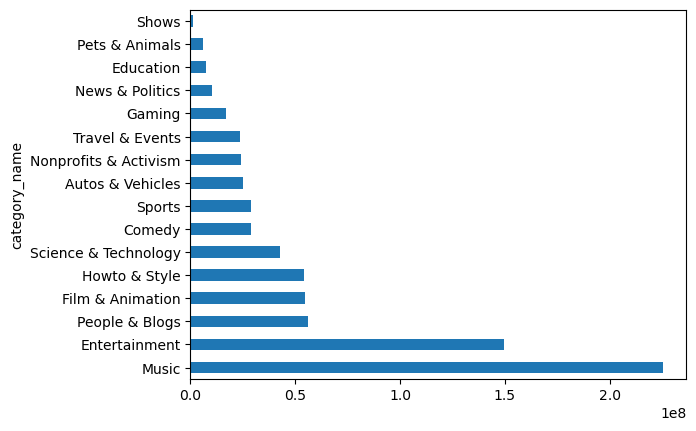

In [6]:
most_viewed_in_each_category = us_df_reduced.groupby("category_name")["views"].max().sort_values(ascending=False)
most_viewed_in_each_category.plot(kind="barh")

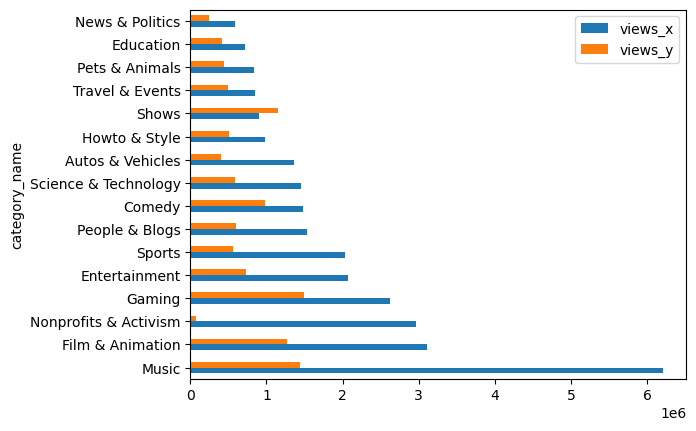

In [15]:
cat_view_mean = us_df_reduced.groupby("category_name")["views"].mean().sort_values(ascending=False)
cat_view_median = us_df_reduced.groupby("category_name")["views"].median().sort_values(ascending=False)

pd.merge(cat_view_mean, cat_view_median, on="category_name").plot(kind="barh")

plt.show()


In [ ]:
plt.plot(us_df_reduced["category_name"] == "Gaming", us_df_reduced["views"])